# Exercises

In [1]:
import numpy as np
import pylab as pl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import psutil
from pathlib import Path
import os

# CaImAn funtions and objects
import caiman as cm
from caiman.motion_correction import MotionCorrect, high_pass_filter_space
from caiman.source_extraction.cnmf import params as params
from caiman.source_extraction import cnmf
from caiman.source_extraction.cnmf.cnmf import load_CNMF

import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data
import auxiliary_functions as aux


import seaborn as sns
sns.set_theme(context='notebook',style='white',font_scale=1.5)


## Exercise 1: Image characteristics
---

**A.** Distiguishing pixels   

Fluctuations in the activitation of the neuron can be directly observed on the video or in a temporal trace plot of each pixel. Plotting the temporal trace will allow us to see the calcium transient dinamic, if a pixel belonging to a neuron is selected. 

* Select a set of *N* random pixels from the ROI and plot the temporal evolution of pixel value. If the random pixels are choosen from an active neuron, you will be able to see the calcium transcient dynamic. Try this a few time to appreciate the results.

**B.** Temporal statistics of pixel activation
 * For the selected pixels, plot the histogram of pixel value. What are the difference in different regions?, and how can that help to distinguish a pixel that belongs to aneuron from a background pixel?

* If we can already see the calcium traces from individual pixels, why do we need to run source extraction to segment the neurons? Why, as a starter, would not be a good idea to work directly with the temporal traces of the pixels? 

A. Distinghuising pixels

Select a set of *N* random pixels from the ROI and plot the temporal evolution of pixel value. If the random pixels are choosen from an active neuron, you will be able to see the calcium transcient dynamic. Try this a few time to appreciate the results.

In [2]:
# download data 
download_data('https://surfdrive.surf.nl/files/index.php/s/yQT6yv34jDu6csE')

# set path to video of the full field of view (FOV) and one to the video that's cropped to only the Region of interest (ROI)
input_tif_file_path_FOV = 'data/calcium_video.tif'    # (FOV)
input_tif_file_path = 'data/caiman_video_trial_0.tif' # (ROI)

FOV = cm.load(input_tif_file_path_FOV) # load video with complete field of view (FOV)

## In the lesson the following code was used for playing the video, I'll put them here for now as they might come in handy later:
## play video (a new window will open)
# FOV.play(gain = 1,  #light intensity of video
#          magnification = 1, #size of display movie
#          fr = 20) # frame rate at which the movie is played

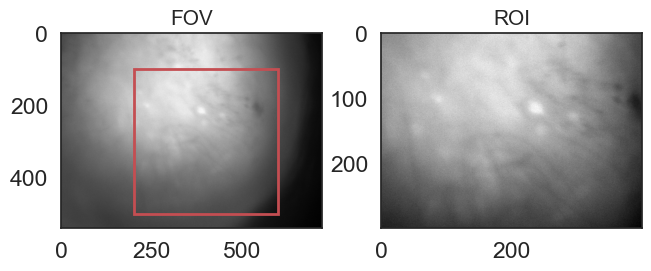

In [ ]:
# Visualization of full FOV and selected ROI
aux.plot_FOV(FOV_file = input_tif_file_path_FOV , ROI_file = input_tif_file_path)

# load movie and compute mean imges with caiman functions
original_movie = cm.load(input_tif_file_path)
mean_image = cm.summary_images.mean_image(input_tif_file_path)
correlation_image, pnr_image = cm.summary_images.correlation_pnr(original_movie,swap_dim=False) # pnr_image is used at the end to plot an example of a correlation image

For the plots of the temporal evolution of the randomly selected pixels I noticed a funtion in the auxilliary functions folder that was made to do exactly this. It wasn't working perfectly so I made some slight changes to it. I don't believe it's used for the lesson notebook so nothing should be broken. See the comments in said folder for what I modified to produce the results below. 

I used the three commented out lines below repeatedly for modification and testing of the function. I decided to leave them in for transparancy

In [4]:
# import importlib
# import auxiliary_functions as aux

# importlib.reload(aux)

c:\Users\Jords\OneDrive - TU Eindhoven\Desktop\NeuroAnalysis\neural-data-master\02-calcium_imaging\code\auxiliary_functions.py:85: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  figure.tight_layout() ## Added this: seems to make plots come out nicer


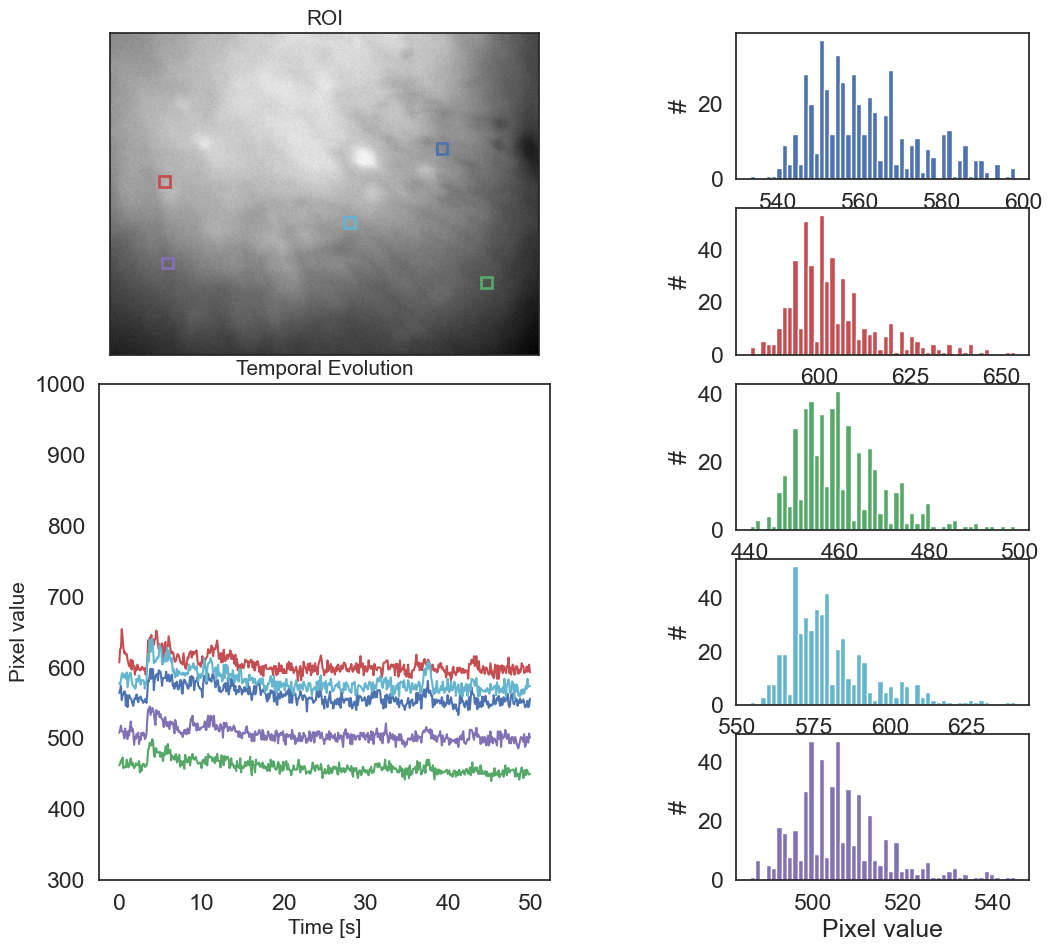

In [5]:
aux.temporal_evolution(file_name= input_tif_file_path, output_file_name='data_exc/random_pixels')

After having ran the function above several times, it appears to me that histograms that belong to active neurons contain broad distributions with sharp peaks and several large outliers (leading to a rightward tail) whereas distributions of pixels that belong to background or inactive neurons have distributions that are very narrow compared to this. Mean value varies depending on the chosen area and, if chosen pixels happen to be close to one another histograms look very similar. 
- These observations reflect why the summary images from the lesson are so helpful: 
    - Broad distributions + large right tail means high peak-to-noise
    - variation in mean value can identify regions with generally greater background noise intensity
    - similarity of histograms of closeby pixels means correlation methods will generally classify nearby pixels properly as noise or background.

## Exercise 2: motion correction parameters
---

One parameter that impacts motion correction performance is the size of the spatial filter that is applyed to the video.

* Use the following function from CaImAn and plot the result of different space filtering applyed to a single frame of the video:from caiman.motion_correction import high_pass_filter_space

* How will this filtering affect the measure of crispness?

* Acording to Pnevmatikakis et al, which other factors are relevant for pw-rigid motion correction?

- Explore the impact of different parameters in the output of motion correction algorithm by measuring crispness in the correlation image of the final outcome. Particularly measure the effect of different spatial filter size by applying motion correction algorithm multiple times and computing the crispness of the output video. 

- Display all crispness values for rigid and not rigid motion correction and plot them agains gSig_filters values.

- If possible, show the impact of the crispness value that comes from changing other relevant paraments.

*Note1: The is no need to save all the motion corrected movies, just save the cripsness values.*

*Note2: gSig_filters is an optional range of posible values, but if your computer gets to slow in the computation reduce the range.*


In [6]:
np.shape(original_movie) # t= 500, x = 300, y = 400 so selection of a single frame i should be like (i, :, :)

(500, 300, 400)

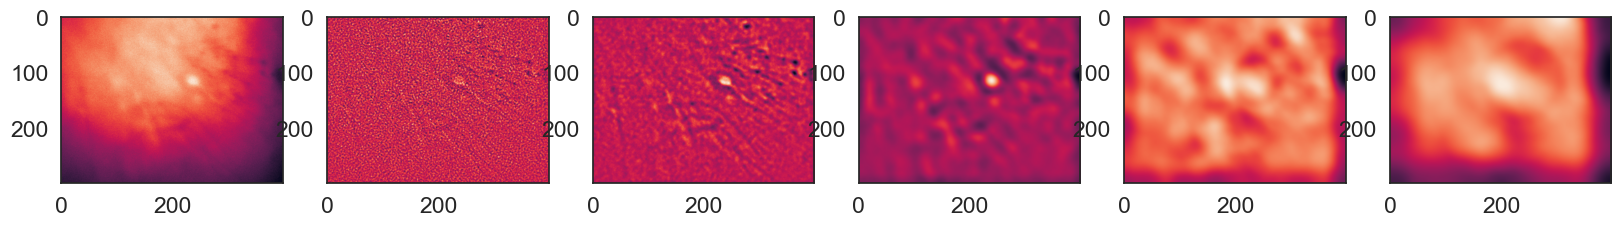

In [7]:
from caiman.motion_correction import high_pass_filter_space

i = 350
# filtersize_x = 5
# filtersize_y = filtersize_x
# filtersize = (filtersize_x,filtersize_y)

or_frame = original_movie[i,:,:]
plt.figure(figsize= [20,10])
plt.subplot(1,6,1)
plt.imshow(or_frame)
filtered_frames = []
filtersizes = [2,5,15,30,50]
for size in filtersizes:
    filtersize = (size,size)
    frame_filtered  = high_pass_filter_space(img_orig= or_frame, gSig_filt= filtersize)
    filtered_frames.append(frame_filtered)

plt.subplot(1,6,2)
plt.imshow(filtered_frames[0])
plt.subplot(1,6,3)
plt.imshow(filtered_frames[1])
plt.subplot(1,6,4)
plt.imshow(filtered_frames[2])
plt.subplot(1,6,5)
plt.imshow(filtered_frames[3])
plt.subplot(1,6,6)
plt.imshow(filtered_frames[4])

Filtering with increasingly larger sizes means filtering over larger patches of space (it broadens the Gaussian used for the filter). This means that increasingly greater patches will become high pass filtered and thus details like edges will become increasingly more blurry. Crispness will therefore decrease

In [8]:
crispness_values = []
filtersizes = [2,5,15,30,50]

In [10]:
n_processes = psutil.cpu_count() # counts local cpus
cm.cluster.stop_server() #stop any already running clusters
# Start a new cluster
c, dview, n_processes = cm.cluster.setup_cluster(backend='multiprocessing',
                                                 n_processes=n_processes,
                                                 single_thread=False)

In [15]:
# Define parameters for motion correction in a dictionary

parameters_motion_correction = { 'pw_rigid': True,       # flag for performing piecewise-rigid motion correction (otherwise just rigid)
                                'gSig_filt': (2, 2),     # size of high pass spatial filtering, used in 1p data
                                'max_shifts': (25, 25),  # maximum allowed rigid shift in pixels (view the movie to get a sense of motion)
                                'niter_rig': 1 ,
                                'strides': (48, 48),     # create a new patch every x pixels for pw-rigid correction
                                'overlaps': (96, 96),    # overlap between pathes (size of patch strides+overlaps)
                                'upsample_factor_grid': 1,
                                'num_frames_split': 80,  # length in frames of each chunk of the movie (to be processed in parallel)
                                'max_deviation_rigid': 15, # maximum deviation allowed for patch with respect to rigid shifts
                                'shifts_opencv': True, 
                                'use_cuda': False, 
                                'nonneg_movie': True,
                                'border_nan': 'copy'}




# We compute and store the minimum value of the movie, that the algorithm needs to make values all positive
original_movie = cm.load(input_tif_file_path)
parameters_motion_correction['min_mov'] = np.min(original_movie) 

# pass parameters to caiman object
opts = params.CNMFParams(params_dict = parameters_motion_correction)


#make directory to save motion corrected videos
Path("data/motion_corrected").mkdir(parents=True, exist_ok=True)

#create an object for motion correction
mc = MotionCorrect(input_tif_file_path, dview = dview, **opts.get_group('motion'))
# Perform rigid motion correction
mc.motion_correct_rigid(save_movie = True, template = None)

#perform non-rigid motion correction
total_template_rig = mc.total_template_rig
mc.motion_correct_pwrigid(save_movie=True, template = total_template_rig)
fname_tot_els = mc.fname_tot_els[0]



final_size = mc.total_template_els.shape
winsize = 100
swap_dim = False
resize_fact_flow = .1    # downsample for computing ROF

tmpl_orig, correlations_orig, flows_orig, norms_orig, crispness_orig = cm.motion_correction.compute_metrics_motion_correction(
    input_tif_file_path, final_size[0], final_size[1], swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow)

tmpl_rig, correlations_rig, flows_rig, norms_rig, crispness_rig = cm.motion_correction.compute_metrics_motion_correction(
    mc.fname_tot_rig[0], final_size[0], final_size[1],
    swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow)

tmpl_els, correlations_els, flows_els, norms_els, crispness_els = cm.motion_correction.compute_metrics_motion_correction(
    mc.fname_tot_els[0], final_size[0], final_size[1],
    swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow)

#crispness calculation
print('Crispness original: '+ str(int(crispness_orig)))
print('Crispness rigid: '+ str(int(crispness_rig)))
print('Crispness elastic: '+ str(int(crispness_els)))





In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.


Crispness original: 1059
Crispness rigid: 1058
Crispness elastic: 1057


In [18]:
crispness_values_orig = []
crispness_values_rig = []
crispness_values_els = []
filtersizes = [2,5,15,30]

for size in filtersizes:
    parameters_motion_correction = { 'pw_rigid': True,       # flag for performing piecewise-rigid motion correction (otherwise just rigid)
                                    'gSig_filt': (size, size),     # size of high pass spatial filtering, used in 1p data
                                    'max_shifts': (25, 25),  # maximum allowed rigid shift in pixels (view the movie to get a sense of motion)
                                    'niter_rig': 1 ,
                                    'strides': (48, 48),     # create a new patch every x pixels for pw-rigid correction
                                    'overlaps': (96, 96),    # overlap between pathes (size of patch strides+overlaps)
                                    'upsample_factor_grid': 1,
                                    'num_frames_split': 80,  # length in frames of each chunk of the movie (to be processed in parallel)
                                    'max_deviation_rigid': 15, # maximum deviation allowed for patch with respect to rigid shifts
                                    'shifts_opencv': True, 
                                    'use_cuda': False, 
                                    'nonneg_movie': True,
                                    'border_nan': 'copy'}




    # We compute and store the minimum value of the movie, that the algorithm needs to make values all positive
    # original_movie = cm.load(input_tif_file_path)
    parameters_motion_correction['min_mov'] = np.min(original_movie) 

    # pass parameters to caiman object
    opts = params.CNMFParams(params_dict = parameters_motion_correction)


    #make directory to save motion corrected videos
    Path("data/motion_corrected").mkdir(parents=True, exist_ok=True)

    #create an object for motion correction
    mc = MotionCorrect(input_tif_file_path, dview = dview, **opts.get_group('motion'))
    # Perform rigid motion correction
    mc.motion_correct_rigid(save_movie = True, template = None)

    #perform non-rigid motion correction
    total_template_rig = mc.total_template_rig
    mc.motion_correct_pwrigid(save_movie=True, template = total_template_rig)
    fname_tot_els = mc.fname_tot_els[0]



    final_size = mc.total_template_els.shape
    winsize = 100
    swap_dim = False
    resize_fact_flow = .1    # downsample for computing ROF

    tmpl_orig, correlations_orig, flows_orig, norms_orig, crispness_orig = cm.motion_correction.compute_metrics_motion_correction(
        input_tif_file_path, final_size[0], final_size[1], swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow)

    tmpl_rig, correlations_rig, flows_rig, norms_rig, crispness_rig = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_rig[0], final_size[0], final_size[1],
        swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow)

    tmpl_els, correlations_els, flows_els, norms_els, crispness_els = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_els[0], final_size[0], final_size[1],
        swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow)

    #crispness calculation
    print('Crispness original: '+ str(int(crispness_orig)))
    print('Crispness rigid: '+ str(int(crispness_rig)))
    print('Crispness elastic: '+ str(int(crispness_els)))
    crispness_values_orig.append(crispness_orig)
    crispness_values_rig.append(crispness_rig)
    crispness_values_els.append(crispness_els)





In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


Crispness original: 1059
Crispness rigid: 1058
Crispness elastic: 1057


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


Crispness original: 1059
Crispness rigid: 858
Crispness elastic: 882


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


Crispness original: 1059
Crispness rigid: 865
Crispness elastic: 905


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.


Crispness original: 1059
Crispness rigid: 1038
Crispness elastic: 934


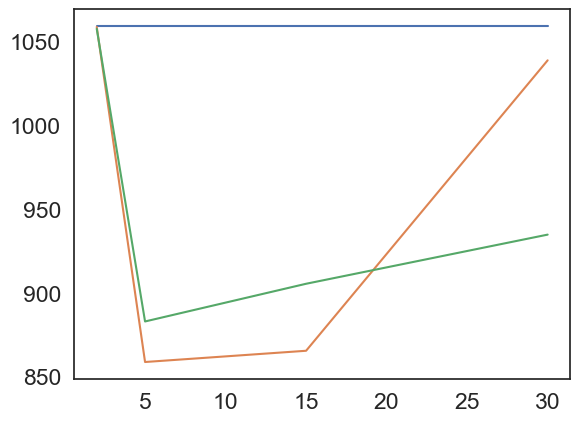

In [21]:
plt.plot(filtersizes, crispness_values_orig)
plt.plot(filtersizes, crispness_values_rig)
plt.plot(filtersizes, crispness_values_els)

## Exercise 3: Source extraction parameters 
---

* For a fixed minimum correlation value (ie 0.6) select a range of possible PNR minimun values and study the impact of those in the final source extraction output.

* For a fixed value of PNR (ie 6) select a range of minimum correlation valur and study the impact of those in the final source extraction output.

* How do these paramenters affect the spatial sparcity of the output? Which set of parameter selection procedes the higher number of neurons? Is maximal number of neurons always better? Why?  

* Generate a plot of number of neurons vs PNR (or min corr value) to show how these parameters affect the source extracted signals.

* Are the temporal traces affected by these parameters?

* For different PNR and minimum correlation value plot the correlation image and the selected cells.

Text(0.5, 1.0, 'PNR image')

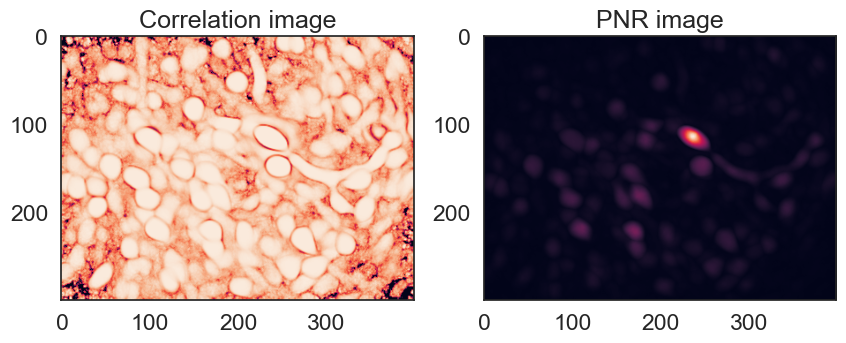

In [23]:
# load motion corrected video
input_mmap_file_path = 'data/motion_corrected/motion_corrected_video_d1_300_d2_400_d3_1_order_C_frames_500.mmap'
Yr, dims, T = cm.load_memmap(input_mmap_file_path)         # load mmap file
images = Yr.T.reshape((T,) + dims, order='F' )

# compute correlation and pnr images 
gSig = 9
corr_image, pnr_image = cm.summary_images.correlation_pnr(images[::1], gSig=gSig,swap_dim=False)

figure, axes = plt.subplots(1, 2,figsize=(10,5))
axes[0].imshow(corr_image)
axes[0].set_title('Correlation image')
axes[1].imshow(pnr_image)
axes[1].set_title('PNR image')
    

In [38]:
pnr_values = [2,7,10,15,20]
N_sources_pnr = []

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


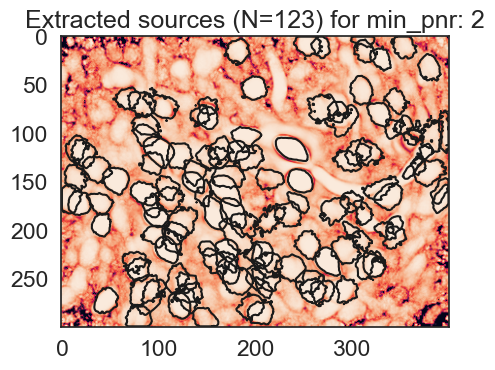

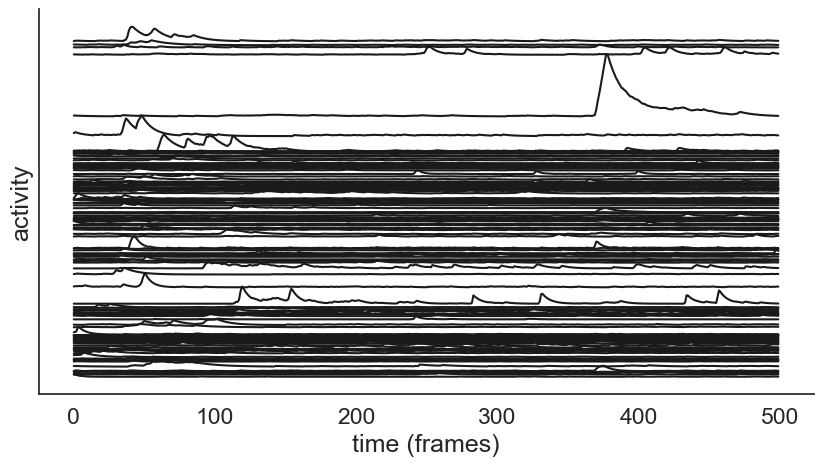

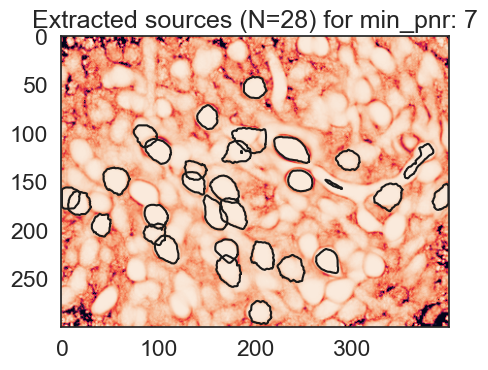

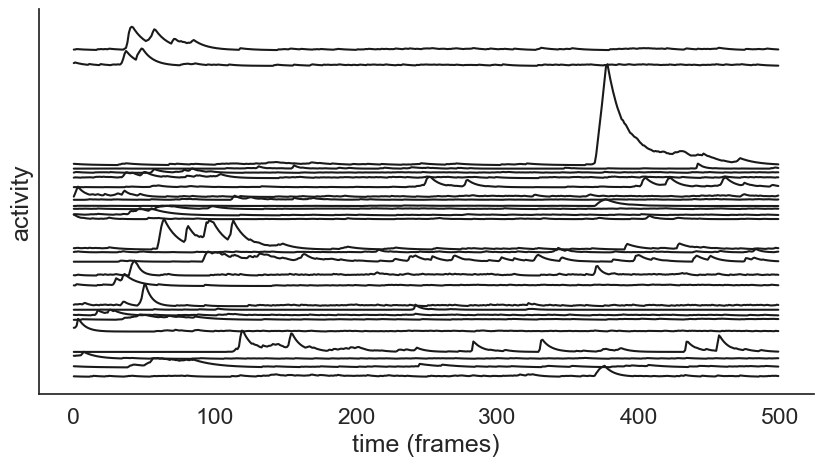

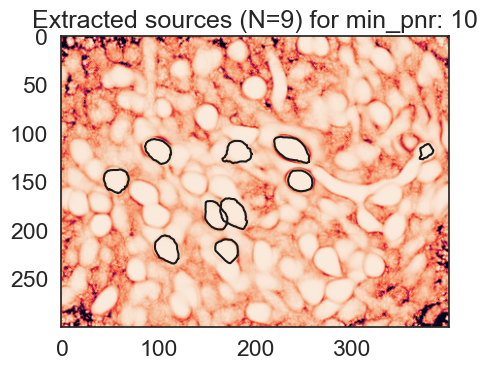

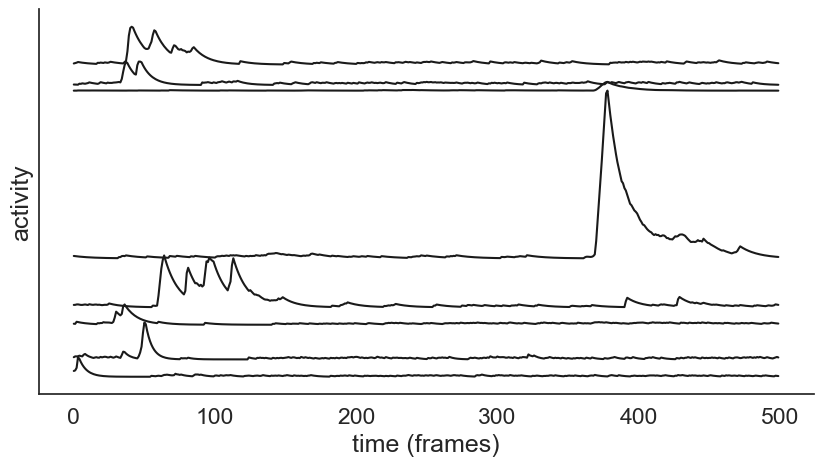

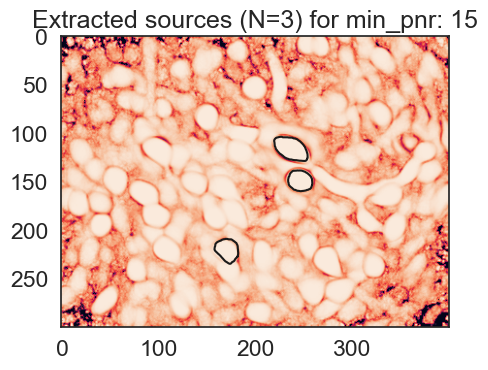

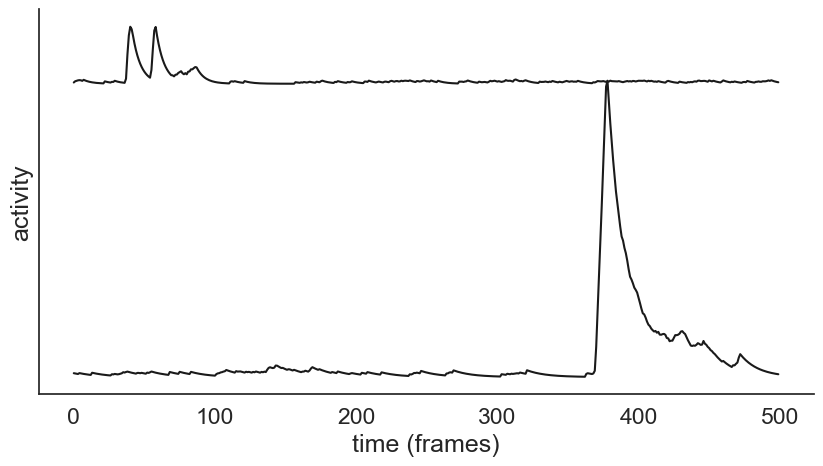

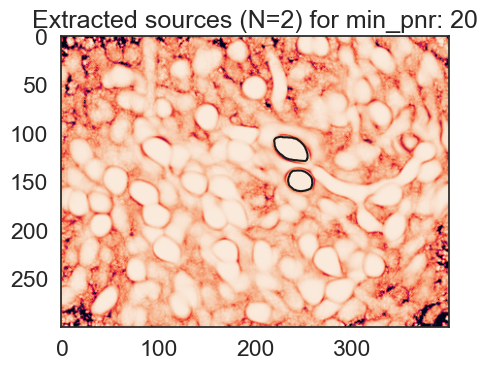

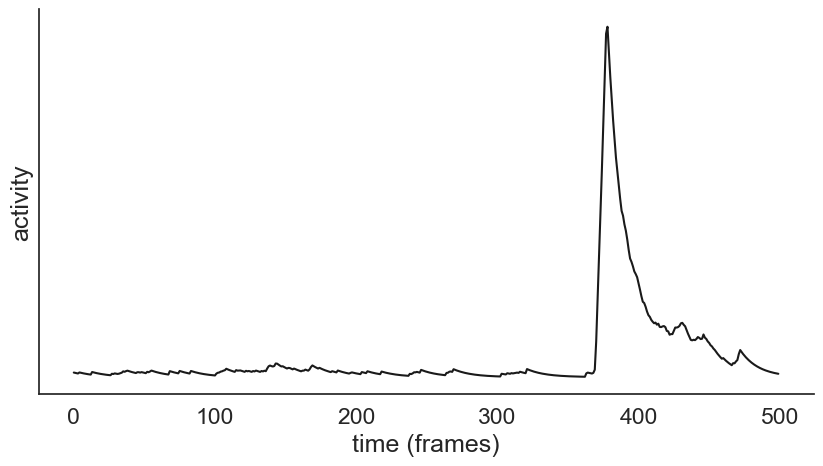

In [39]:
# create dictionary with source extraction parameters
for pnr in pnr_values:
    parameters_source_extraction ={ 'fr': 10,               # movie frame rate
                                'decay_time': 0.1,       # length of a typical transient in seconds
                                'min_corr': 0.6,   # min peak value from correlation image
                                'min_pnr': pnr,     # min peak to noise ration from PNR image
                                    'p': 1,                # order of the autoregressive system 
                                'K': None,              # upper bound on number of components per patch, in general None
                                'gSig': (4, 4),         # gaussian width of a 2D gaussian kernel, which approximates a neuron
                                'gSiz': (17, 17),       # average diameter of a neuron, in general 4*gSig+1
                                'ring_size_factor': 1.4, # radius of ring is gSiz*ring_size_factor
                                'merge_thr': 0.7, 'rf': 60,
                                'stride': 30, 'tsub': 1, 'ssub': 2, 'p_tsub': 1, 'p_ssub': 2, 'low_rank_background': None,
                                'nb': 0, 'nb_patch': 0, 'ssub_B': 2, 'init_iter': 2,
                                'method_init': 'corr_pnr', 'method_deconvolution': 'oasis',
                                'update_background_components': True,
                                'center_psf': True, 'border_pix': 0, 'normalize_init': False,
                                'del_duplicates': True, 'only_init': True}
    # create caiman parameters objects
    opts = params.CNMFParams(params_dict=parameters_source_extraction)

    cnmf_object = cnmf.CNMF(n_processes=n_processes, dview=dview, params=opts)
    cnmf_object.fit(images)

    # Save the cnmf object as a hdf5 file
    Path("data/source_extracted_exc").mkdir(parents=True, exist_ok=True)
    output_cnmf_file_path = 'data/source_extracted_exc/calcium_video_0_cnmf.hdf5'
    cnmf_object.save(output_cnmf_file_path)

    # display footprints in the ROI
    figure, axes = plt.subplots(1,figsize=(5,5))
    plt.title(f'Extracted sources (N={cnmf_object.estimates.A.shape[1]}) for min_pnr: {pnr}')
    pos = axes.imshow(corr_image)
    coordinates = cm.utils.visualization.get_contours(cnmf_object.estimates.A, np.shape(corr_image), 0.2, 'max')
    for c in coordinates:
        v = c['coordinates']
        c['bbox'] = [np.floor(np.nanmin(v[:, 1])), np.ceil(np.nanmax(v[:, 1])),
                        np.floor(np.nanmin(v[:, 0])), np.ceil(np.nanmax(v[:, 0]))]
        axes.plot(*v.T, c='k')

    # plot temporal traces
    figure, axes = plt.subplots(1,figsize=(10,5))
    C_0 = cnmf_object.estimates.C.copy()
    C_0[1] += C_0[0].min()
    for i in range(1, len(C_0)):
        C_0[i] += C_0[i].min() + C_0[:i].max()
        axes.plot(C_0[i],c='k')
    axes.set_xlabel('time (frames)')
    axes.set_yticks([])
    sns.despine()
    axes.set_ylabel('activity')
    N_sources_pnr.append(cnmf_object.estimates.A.shape[1])



Raising the minimum peak to noise value treshold results in an increasingly stricter requirement for a neuron to be considered active by the algorithm. This therefore means that with increasing pnr a decreasing number of regions are identified to be sources of activity and fewer temporal traces will be plotted. The traces that are plotted however remain the same

In [40]:
corr_values = [0.1, 0.3, 0.5, 0.7, 0.9]
N_sources_corr = []

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


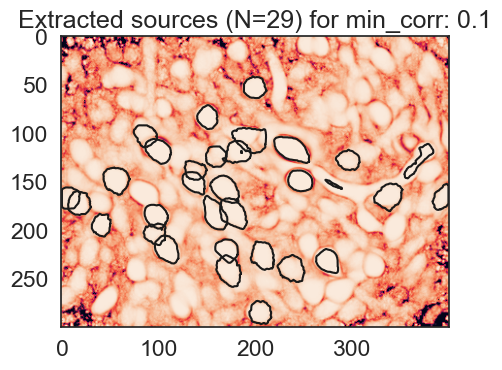

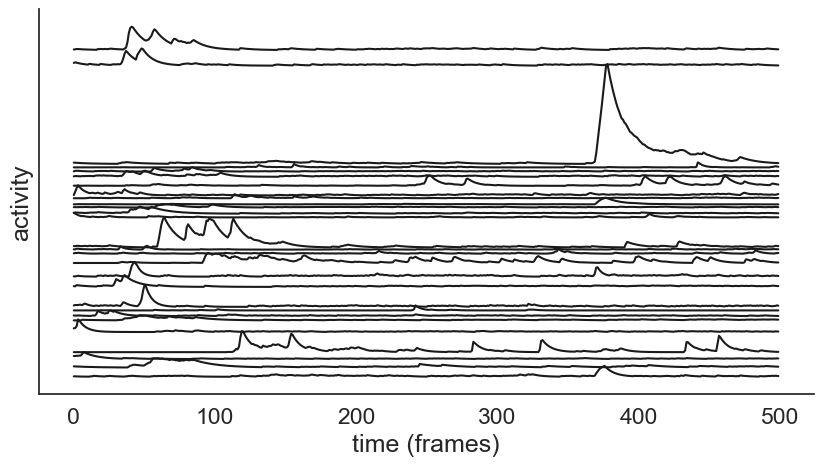

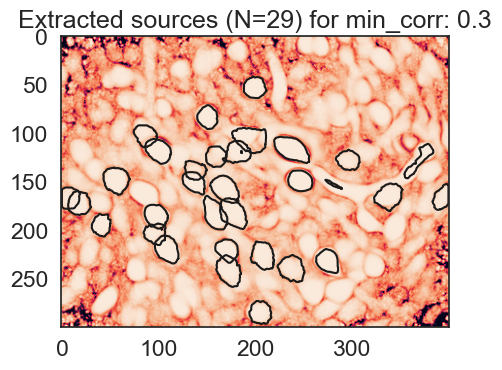

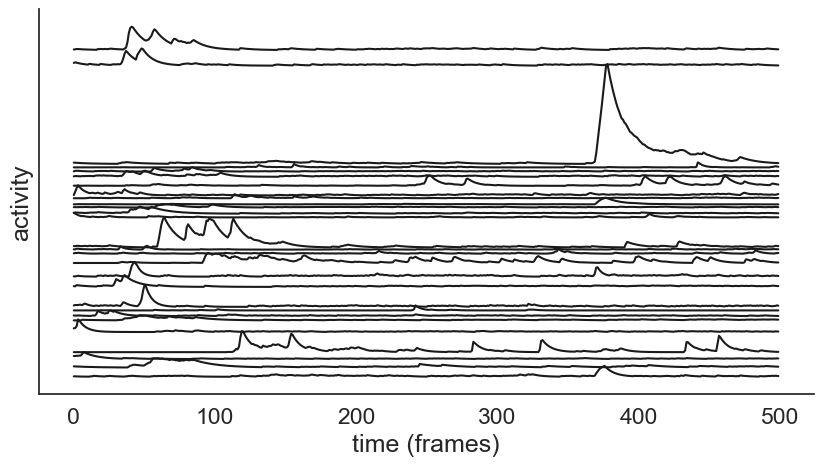

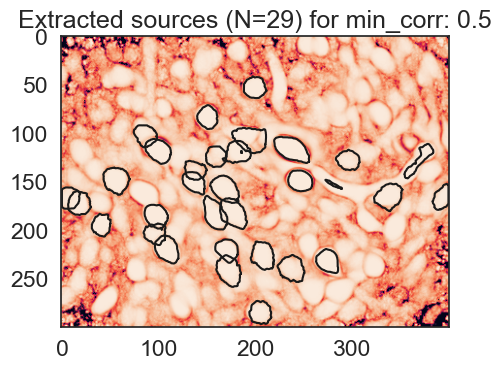

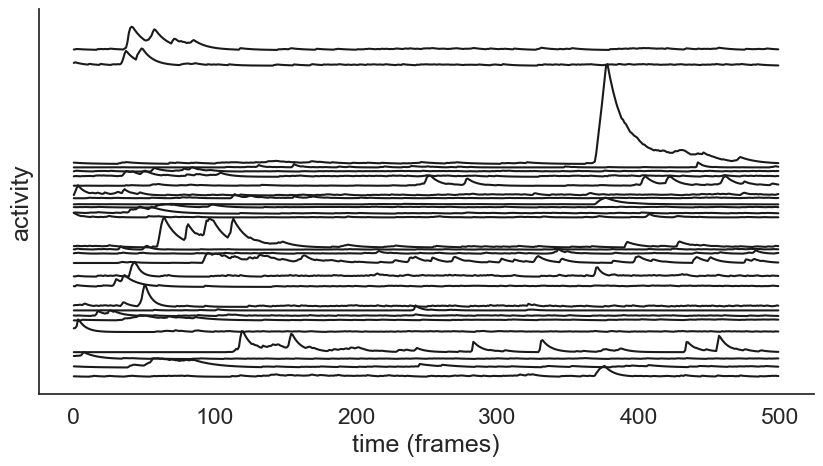

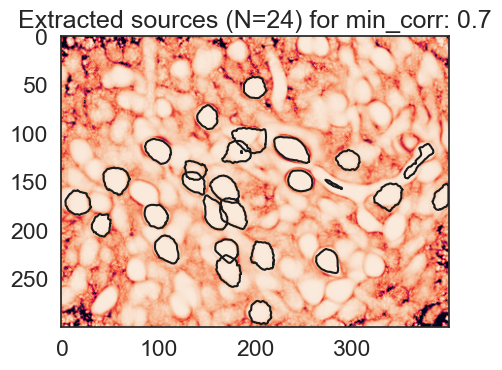

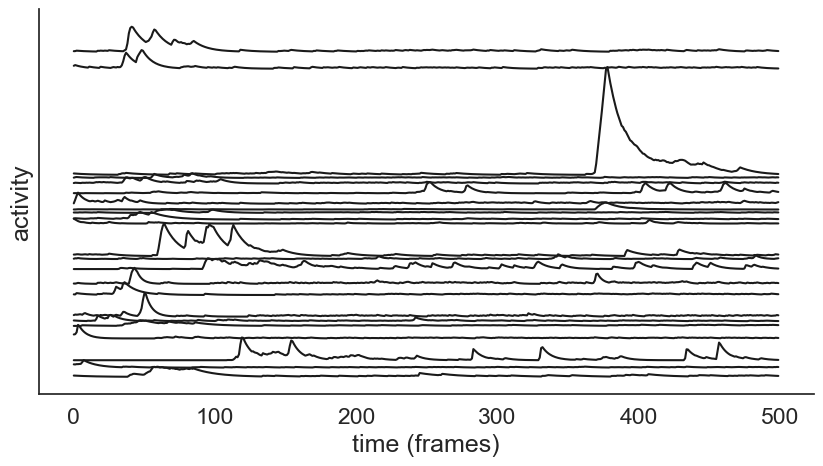

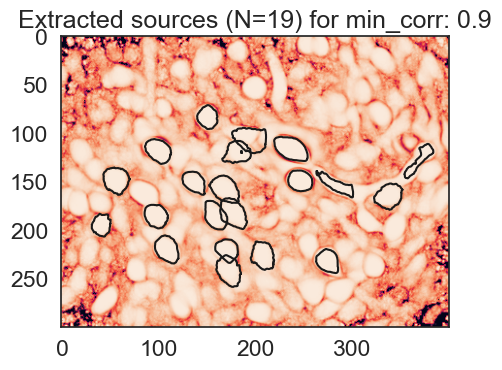

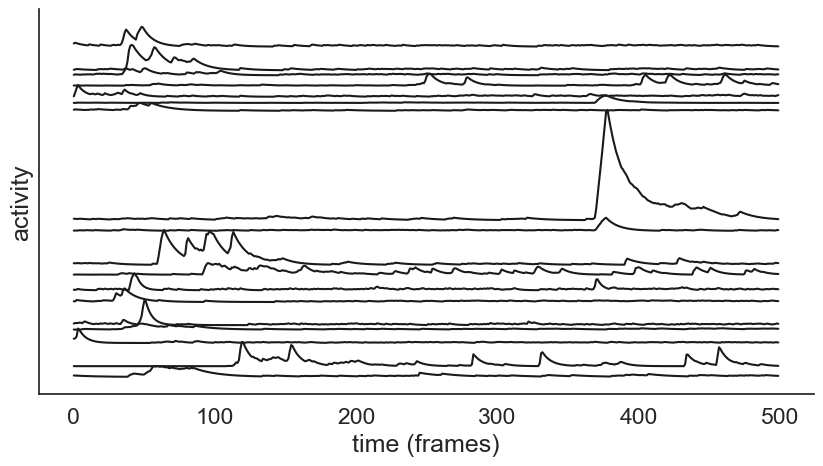

In [41]:
# create dictionary with source extraction parameters
for corr in corr_values:
    parameters_source_extraction ={ 'fr': 10,               # movie frame rate
                                'decay_time': 0.1,       # length of a typical transient in seconds
                                'min_corr': corr,   # min peak value from correlation image
                                'min_pnr': 7,     # min peak to noise ration from PNR image
                                    'p': 1,                # order of the autoregressive system 
                                'K': None,              # upper bound on number of components per patch, in general None
                                'gSig': (4, 4),         # gaussian width of a 2D gaussian kernel, which approximates a neuron
                                'gSiz': (17, 17),       # average diameter of a neuron, in general 4*gSig+1
                                'ring_size_factor': 1.4, # radius of ring is gSiz*ring_size_factor
                                'merge_thr': 0.7, 'rf': 60,
                                'stride': 30, 'tsub': 1, 'ssub': 2, 'p_tsub': 1, 'p_ssub': 2, 'low_rank_background': None,
                                'nb': 0, 'nb_patch': 0, 'ssub_B': 2, 'init_iter': 2,
                                'method_init': 'corr_pnr', 'method_deconvolution': 'oasis',
                                'update_background_components': True,
                                'center_psf': True, 'border_pix': 0, 'normalize_init': False,
                                'del_duplicates': True, 'only_init': True}
    # create caiman parameters objects
    opts = params.CNMFParams(params_dict=parameters_source_extraction)

    cnmf_object = cnmf.CNMF(n_processes=n_processes, dview=dview, params=opts)
    cnmf_object.fit(images)

    # Save the cnmf object as a hdf5 file
    Path("data/source_extracted_exc").mkdir(parents=True, exist_ok=True)
    output_cnmf_file_path = 'data/source_extracted_exc/calcium_video_0_cnmf.hdf5'
    cnmf_object.save(output_cnmf_file_path)

    # display footprints in the ROI
    figure, axes = plt.subplots(1,figsize=(5,5))
    plt.title(f'Extracted sources (N={cnmf_object.estimates.A.shape[1]}) for min_corr: {corr}')
    pos = axes.imshow(corr_image)
    coordinates = cm.utils.visualization.get_contours(cnmf_object.estimates.A, np.shape(corr_image), 0.2, 'max')
    for c in coordinates:
        v = c['coordinates']
        c['bbox'] = [np.floor(np.nanmin(v[:, 1])), np.ceil(np.nanmax(v[:, 1])),
                        np.floor(np.nanmin(v[:, 0])), np.ceil(np.nanmax(v[:, 0]))]
        axes.plot(*v.T, c='k')

    # plot temporal traces
    figure, axes = plt.subplots(1,figsize=(10,5))
    C_0 = cnmf_object.estimates.C.copy()
    C_0[1] += C_0[0].min()
    for i in range(1, len(C_0)):
        C_0[i] += C_0[i].min() + C_0[:i].max()
        axes.plot(C_0[i],c='k')
    axes.set_xlabel('time (frames)')
    axes.set_yticks([])
    sns.despine()
    axes.set_ylabel('activity')
    N_sources_corr.append(cnmf_object.estimates.A.shape[1])



Lowering min_corr results in the identification of more sources. It should be noted that, from a value of ~0.5 the number of sources identified seems to maximize at N=29 see also the plots below

Text(0, 0.5, 'number of sources')

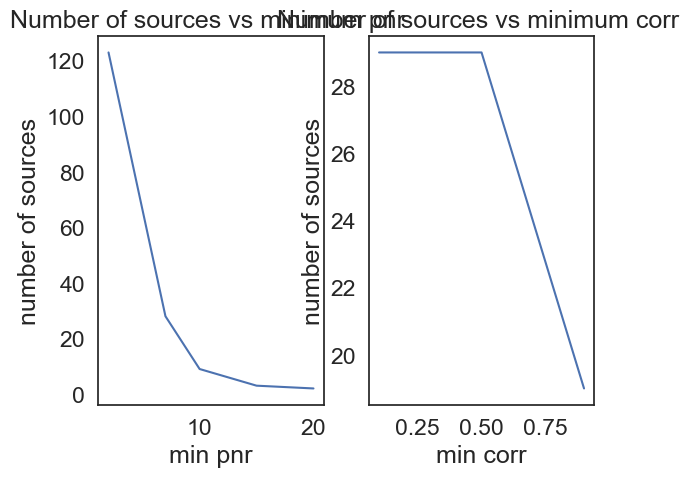

In [43]:
plt.figure()
plt.subplot(1,2,1)
plt.plot(pnr_values, N_sources_pnr)
plt.title("Number of sources vs minimum pnr ")
plt.xlabel("min pnr")
plt.ylabel("number of sources")
plt.subplot(1,2,2)
plt.plot(corr_values, N_sources_corr)
plt.title("Number of sources vs minimum corr ")
plt.xlabel("min corr")
plt.ylabel("number of sources")


Altrering the parameters in such a way that the number of sources is maximized is desirable when it is possible to allocate enough time for reviewing the produced images. Since in this way one can be the most sure that none are missed. However, there can also be instances where it is simply not possible to allocate much time and resources for scrutinizing the produced data or it might be the case that the absolute number of active neurons isn't the most important value of interest for the researcher but rather the activity traces themselves are. In such cases, more conservative choices of parameters can be used to ensure that only the best examples of activity are selected.